In [1]:
import os
from field import Field
field = Field(os.path.dirname(os.getcwd()) +"/Nov6/FieldID_2392987.json")

In [2]:
iso_x = field.isocentre["x"]
iso_y = field.isocentre['y']

control_point = field.mq_control_points[0]

leaf_width = field.leaf_width
num_leaves = len(field.mq_control_points[0]["leafSetA"])


In [3]:
leaf_width

0.5

In [4]:
def rotate(x,y,theta,is_x):
    from math import cos, sin, radians
    if is_x:
        return x*cos(radians(theta)) - y*sin(radians(theta))
    return x*sin(radians(theta)) + y*cos(radians(theta))


(-5.0, 25.0)

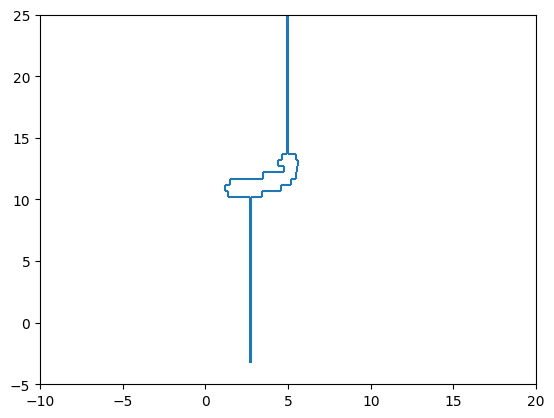

In [5]:
import matplotlib.pyplot as plt


control_point = field.mq_control_points[0]

collimatorAngle = control_point["collimatorAngle"]

fig,ax = plt.subplots()
i = 0

start = -num_leaves//2*leaf_width
end = start+ leaf_width
while end < num_leaves/2*leaf_width -1:
    ax1 = control_point['leafSetA'][i] + iso_x
    ax2 = control_point['leafSetA'][i+1] + iso_x
    bx1 = -control_point['leafSetB'][i] + iso_x
    bx2 = -control_point['leafSetB'][i+1] + iso_x
    y1 = iso_y + start
    y2 = iso_y + end
    
    ax.vlines(ax1, y1,y2)
    ax.hlines(y2, ax1, ax2)
    ax.vlines(bx1, y1,y2)
    ax.hlines(y2, bx1, bx2)
    
    start += leaf_width
    end += leaf_width
    i += 1

plt.xlim((-10,20))
plt.ylim((-5,25))


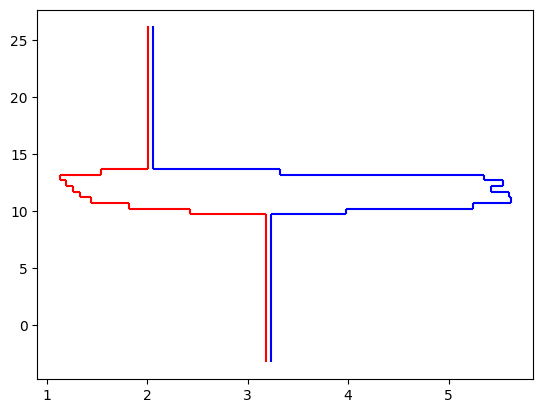

In [6]:
control_point = field.mq_control_points[40]


fig,ax = plt.subplots()
i = 0

start = -num_leaves//2*leaf_width
end = start+ leaf_width
while end < num_leaves/2*leaf_width:
    ax.vlines(iso_x + control_point['leafSetA'][i], iso_y + start,iso_y + end, color = "blue")
    ax.hlines(iso_y + end, iso_x +control_point['leafSetA'][i], iso_x +control_point['leafSetA'][i+1], color = "blue")
    ax.vlines(iso_x -control_point['leafSetB'][i], iso_y + start,iso_y + end, color = "red")
    ax.hlines(iso_y + end, iso_x -control_point['leafSetB'][i], iso_x-control_point['leafSetB'][i+1], color = "red")
    
    start += leaf_width
    end += leaf_width
    i += 1


## Elektas

In [7]:
file = os.path.dirname(os.getcwd()) + "\\Nov6\\" + "FieldID_2393324.json"
varian_field = Field(file)

In [8]:
varian_field.mq_control_points[0]['mlcLeaves']//len(field.mq_control_points)

0

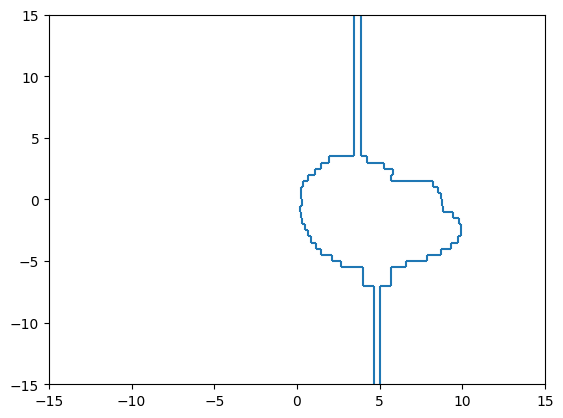

In [11]:


iso_x = 0#field.isocentre["x"]
iso_y = 0#field.isocentre['y']

leaf_width = varian_field.leaf_width
num_leaves = len(varian_field.mq_control_points[0]["leafSetA"])

control_point = varian_field.mq_control_points[-1]

fig,ax = plt.subplots()
i = 0

start = num_leaves//2*leaf_width
end = start - leaf_width
while end > -num_leaves/2*leaf_width+leaf_width:
    ax.vlines(iso_x + control_point['leafSetA'][i], iso_y + start,iso_y + end)
    ax.hlines(iso_y + end, iso_x +control_point['leafSetA'][i], iso_x +control_point['leafSetA'][i+1])
    ax.vlines(iso_x -control_point['leafSetB'][i], iso_y + start,iso_y + end)
    ax.hlines(iso_y + end, iso_x -control_point['leafSetB'][i], iso_x-control_point['leafSetB'][i+1])
    
    start -= leaf_width
    end -= leaf_width
    i += 1

plt.xlim((-15+iso_x,15+iso_x))
plt.ylim((-15+iso_y,15+iso_y))
plt.show()